In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils import resample


In [2]:
df = pd.read_csv(r"C:\Venuki IIT\4th Sem\DSGP\Proj\Hotel-A-train_cleaned.CSV")
df['Reservation_Status'] = df['Reservation_Status'].replace('Check-out', 'Check-Out')


df['Expected_checkin']  = pd.to_datetime(df['Expected_checkin'],  errors='coerce')
df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'], errors='coerce')
df['Booking_date']      = pd.to_datetime(df['Booking_date'],      errors='coerce')

print('Shape:', df.shape)
print('\nTarget distribution:')
print(df['Reservation_Status'].value_counts())


Shape: (26993, 26)

Target distribution:
Reservation_Status
Check-Out    20777
Canceled      4108
No-Show       2108
Name: count, dtype: int64


## 3. Feature Engineering
Adding 13 new features derived from existing columns to improve class separability.


In [3]:
# ── Party & booking features 
df['Party_Size']     = df['Adults'] + df['Children'] + df['Babies']   # total guests
df['Is_Family']      = ((df['Children'] > 0) | (df['Babies'] > 0)).astype(int)
df['Has_Discount']   = (df['Discount_Rate'] > 0).astype(int)
         # total $ at stake
# Actual amount the guest pays after discount
df['Actual_Room_Rate']   = df['Room_Rate'] * (1 - df['Discount_Rate'] / 100)
df['Revenue_At_Risk']    = df['Actual_Room_Rate'] * df['Length_of_Stay']

# ── Date-based features 
df['Checkin_Month']      = df['Expected_checkin'].dt.month
df['Checkin_DayOfWeek']  = df['Expected_checkin'].dt.dayofweek          # 0=Mon, 6=Sun
df['Is_Weekend_Checkin'] = (df['Checkin_DayOfWeek'] >= 4).astype(int)  # Fri/Sat/Sun
df['Booking_Month']      = df['Booking_date'].dt.month
df['Booking_DayOfWeek']  = df['Booking_date'].dt.dayofweek
df['Is_HighSeason']      = df['Checkin_Month'].isin([6,7,8,12]).astype(int)

# ── Interaction terms 
df['PrevCancel_x_LeadTime'] = (df['Previous_Cancellations']=='Yes').astype(int) * df['Lead_Time']
df['NoDeposit_x_LeadTime']  = (df['Deposit_type']=='No Deposit').astype(int) * df['Lead_Time']
df['Online_x_NoDeposit']    = ((df['Booking_channel']=='Online') & (df['Deposit_type']=='No Deposit')).astype(int)

# Drop raw date columns (now captured in engineered features)
df = df.drop(columns=['Reservation-id','Expected_checkin','Expected_checkout','Booking_date'], errors='ignore')

print('Features after engineering:', df.shape[1])
print('New features added: Party_Size, Is_Family, Has_Discount, Revenue_At_Risk,')
print('  Checkin_Month, Checkin_DayOfWeek, Is_Weekend_Checkin, Booking_Month,')
print('  Booking_DayOfWeek, Is_HighSeason, PrevCancel_x_LeadTime,')
print('  NoDeposit_x_LeadTime, Online_x_NoDeposit')


Features after engineering: 36
New features added: Party_Size, Is_Family, Has_Discount, Revenue_At_Risk,
  Checkin_Month, Checkin_DayOfWeek, Is_Weekend_Checkin, Booking_Month,
  Booking_DayOfWeek, Is_HighSeason, PrevCancel_x_LeadTime,
  NoDeposit_x_LeadTime, Online_x_NoDeposit


## 4. Define Features & Target

In [4]:
numeric_features = [
    'Age','Adults','Children','Babies','Discount_Rate','Room_Rate','Lead_Time','Length_of_Stay',
    # Engineered
    'Party_Size','Is_Family','Has_Discount','Revenue_At_Risk',
    'Checkin_Month','Checkin_DayOfWeek','Is_Weekend_Checkin',
    'Booking_Month','Booking_DayOfWeek','Is_HighSeason',
    'PrevCancel_x_LeadTime','NoDeposit_x_LeadTime','Online_x_NoDeposit'
]
categorical_features = [
    'Gender','Ethnicity','Educational_Level','Income','Country_region',
    'Hotel_Type','Meal_Type','Visted_Previously','Previous_Cancellations',
    'Deposit_type','Booking_channel','Required_Car_Parking','Use_Promotion'
]

X = df[numeric_features + categorical_features]
y = df['Reservation_Status']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print('Classes:', dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))
print(f'Total features: {len(numeric_features)} numeric + {len(categorical_features)} categorical = {len(numeric_features)+len(categorical_features)}')


Classes: {'Canceled': 0, 'Check-Out': 1, 'No-Show': 2}
Total features: 21 numeric + 13 categorical = 34


## 5. Preprocessing Pipeline

In [5]:
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])


## 6. Train-Test Split & Oversampling

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Manual oversampling — replace with SMOTE if imblearn is available
def oversample_to_majority(X, y):
    unique, counts = np.unique(y, return_counts=True)
    max_count = counts.max()
    X_parts, y_parts = [], []
    for cls in unique:
        mask = y == cls
        Xc, yc = resample(X[mask], y[mask], replace=True, n_samples=max_count, random_state=42)
        X_parts.append(Xc); y_parts.append(yc)
    return np.vstack(X_parts), np.concatenate(y_parts)

X_balanced, y_balanced = oversample_to_majority(X_train_proc, y_train)

unique, counts = np.unique(y_balanced, return_counts=True)
print('Balanced class distribution:')
for c, n in zip(label_encoder.classes_[unique], counts):
    print(f'  {c}: {n}')


Balanced class distribution:
  Canceled: 16621
  Check-Out: 16621
  No-Show: 16621


## 7. Train Gradient Boosting

In [8]:
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)

gb.fit(X_balanced, y_balanced)
print('Training complete!')


Training complete!


## 8. Evaluate

In [9]:
y_pred  = gb.predict(X_test_proc)
y_proba = gb.predict_proba(X_test_proc)

print('='*60)
print('GRADIENT BOOSTING — CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}  (Baseline: 0.4944  |  Improvement: +2.35pp)')


GRADIENT BOOSTING — CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Canceled       0.21      0.38      0.27       822
   Check-Out       0.86      0.57      0.68      4156
     No-Show       0.10      0.28      0.15       421

    accuracy                           0.52      5399
   macro avg       0.39      0.41      0.37      5399
weighted avg       0.70      0.52      0.58      5399

Accuracy: 0.5160  (Baseline: 0.4944  |  Improvement: +2.35pp)


## 9. Before vs After Feature Engineering

In [ ]:
# Visualise precision / recall / f1 improvement per class

## 10. Confusion Matrix

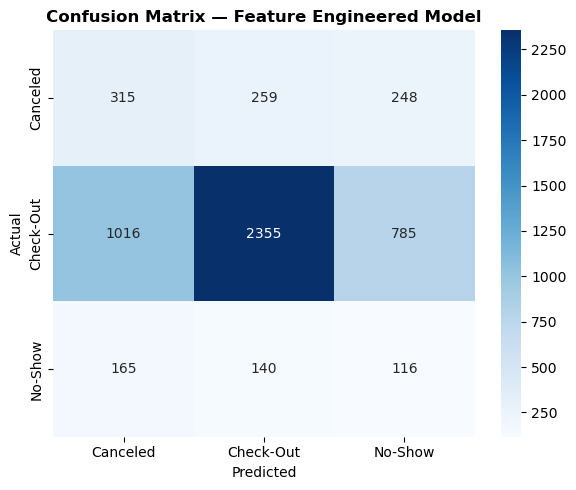

In [10]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Feature Engineered Model', fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Feature Importance
> Green bars = newly engineered features. Several of them ranked in the top 10!


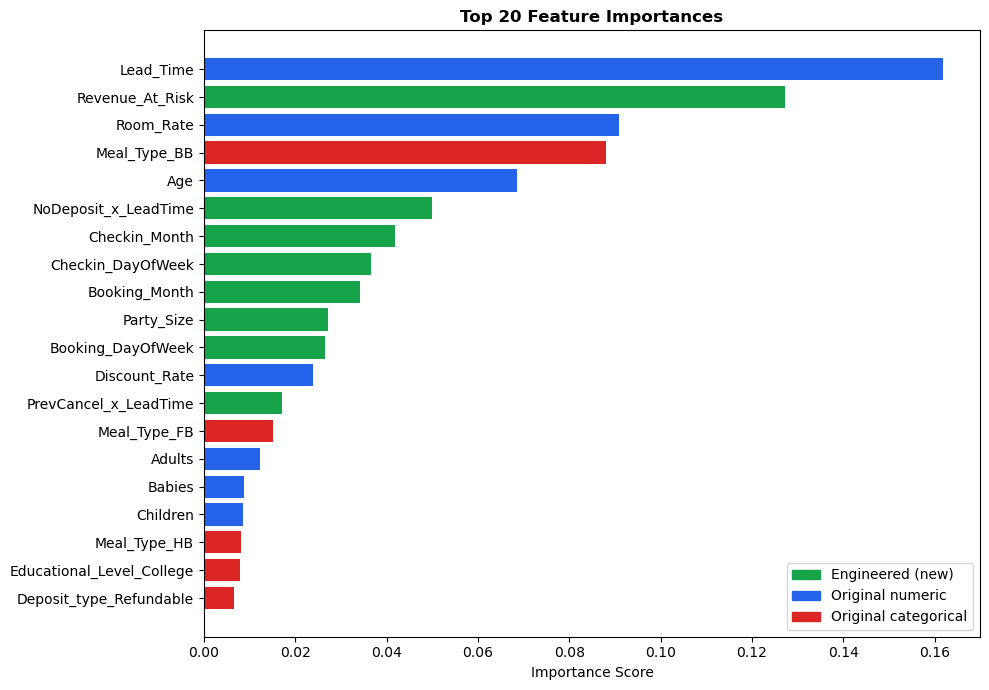

In [11]:
ohe_names  = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(categorical_features).tolist()
all_feat   = numeric_features + ohe_names
feat_df    = pd.DataFrame({'feature': all_feat, 'importance': gb.feature_importances_})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)

engineered = ['Party_Size','Is_Family','Has_Discount','Revenue_At_Risk','Checkin_Month',
              'Checkin_DayOfWeek','Is_Weekend_Checkin','Booking_Month','Booking_DayOfWeek',
              'Is_HighSeason','PrevCancel_x_LeadTime','NoDeposit_x_LeadTime','Online_x_NoDeposit']
colors = ['#16a34a' if f in engineered else '#2563eb' if f in numeric_features else '#dc2626'
          for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10,7))
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importance Score'); ax.set_title('Top 20 Feature Importances', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#16a34a',label='Engineered (new)'),
                   Patch(color='#2563eb',label='Original numeric'),
                   Patch(color='#dc2626',label='Original categorical')])
plt.tight_layout(); plt.show()


## 12. Score a New Booking

In [12]:
new_booking = pd.DataFrame([{
    'Age': 35, 'Adults': 2, 'Children': 1, 'Babies': 0,
    'Discount_Rate': 10, 'Room_Rate': 180, 'Lead_Time': 60, 'Length_of_Stay': 2,
    'Party_Size': 3, 'Is_Family': 1, 'Has_Discount': 1, 'Revenue_At_Risk': 360,
    'Checkin_Month': 7, 'Checkin_DayOfWeek': 4, 'Is_Weekend_Checkin': 1,
    'Booking_Month': 5, 'Booking_DayOfWeek': 1, 'Is_HighSeason': 1,
    'PrevCancel_x_LeadTime': 0, 'NoDeposit_x_LeadTime': 60, 'Online_x_NoDeposit': 1,
    'Gender': 'F', 'Ethnicity': 'caucasian', 'Educational_Level': 'Grad',
    'Income': '50K -- 100K', 'Country_region': 'North', 'Hotel_Type': 'City Hotel',
    'Meal_Type': 'BB', 'Visted_Previously': 'No', 'Previous_Cancellations': 'No',
    'Deposit_type': 'No Deposit', 'Booking_channel': 'Online',
    'Required_Car_Parking': 'No', 'Use_Promotion': 'Yes'
}])

new_proc   = preprocessor.transform(new_booking)
pred_label = label_encoder.inverse_transform(gb.predict(new_proc))
pred_proba = gb.predict_proba(new_proc)

print('Predicted Status:', pred_label[0])
print('\nProbabilities:')
for cls, p in zip(label_encoder.classes_, pred_proba[0]):
    bar = '█' * int(p*30)
    print(f'  P({cls:<10}) = {p:.3f}  {bar}')


Predicted Status: Check-Out

Probabilities:
  P(Canceled  ) = 0.267  ████████
  P(Check-Out ) = 0.526  ███████████████
  P(No-Show   ) = 0.207  ██████
